### Significant Earthquake

Rows (records): 37,331

Columns (features): 23

Target :Mag

This project uses a dataset containing information about significant earthquakes that occurred between 1900 and 2023. The dataset includes details such as time, location, latitude, longitude, depth, and magnitude of earthquakes.

Earthquakes are natural disasters that can cause severe damage to human life and property. Therefore, understanding the relationship between earthquake magnitude, depth, and geographical location is very important.

The main objective of this project is to:

* Analyze historical earthquake data using Exploratory Data Analysis (EDA),

* Study the frequency and distribution of earthquakes,

* Identify regions where high-magnitude earthquakes occur more frequently,

* Examine the relationship between earthquake depth and magnitude.

***Explanation of Dataset Features*** :

* **Time**: Date and time when the earthquake occurred.

* **Place**: Description of the location where the earthquake occurred.

* **Latitude**: North–south geographical coordinate of the earthquake location.

* **Longitude**: East–west geographical coordinate of the earthquake location.

* **Depth**: Depth of the earthquake focus below the Earth’s surface (in kilometers).

* **`Mag`**: Magnitude of the earthquake, representing its strength.

* **MagType**: Type of magnitude scale used (e.g., Mw, Mb, ML).

* **nst**: Number of seismic stations that reported the earthquake.

* **gap**: Largest azimuthal gap between seismic stations (in degrees).

* **dmin**: Minimum distance from the earthquake to the nearest seismic station.

* **rms**: Root Mean Square of travel time residuals, indicating data quality.

* **net**: Seismic network that detected the earthquake.

* **ID**: Unique identifier for each earthquake event.

* **Updated**: Last updated time of the earthquake record.

* **Unnamed**: 14: Empty or irrelevant column (can be removed during data cleaning).

* **Type**: Type of seismic event (e.g., earthquake, explosion).

* **horizontalError**: Estimated horizontal location error (in kilometers).

* **depthError**: Estimated error in depth measurement.

* **magError**: Estimated error in magnitude calculation.

* **magNst**: Number of stations used to calculate magnitude.

* **status**: Review status of the earthquake record (automatic or reviewed).

* **locationSource**: Source agency that provided the location data.

* **magSource**: Source agency that provided the magnitude data.


These features collectively describe the time, location, strength, accuracy, and source information of each earthquake event, enabling detailed exploratory data analysis and risk assessment.

## Import Libraries

In [642]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

https://www.kaggle.com/datasets/jahaidulislam/significant-earthquake-dataset-1900-2023

In [643]:
# Load dataset
df = pd.read_csv("Significant Earthquake Dataset 1900-2023.csv")

df.head()

,Time,Place,Latitude,Longitude,Depth,Mag,MagType,nst,gap,dmin,...,Updated,Unnamed: 14,Type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2023-02-17T09:37:34.868Z,"130 km SW of Tual, Indonesia",-6.5986,132.0763,38.615,6.1,mww,119.0,51.0,2.988,...,2023-02-17T17:58:24.040Z,NaN,earthquake,6.41,5.595,0.065,23.0,reviewed,us,us
1,2023-02-16T05:37:05.138Z,"7 km SW of Port-Olry, Vanuatu",-15.0912,167.0294,36.029,5.6,mww,81.0,26.0,0.392,...,2023-02-17T05:41:32.448Z,NaN,earthquake,5.99,6.080,0.073,18.0,reviewed,us,us
2,2023-02-15T18:10:10.060Z,"Masbate region, Philippines",12.3238,123.8662,20.088,6.1,mww,148.0,47.0,5.487,...,2023-02-16T20:12:32.595Z,NaN,earthquake,8.61,4.399,0.037,71.0,reviewed,us,us
3,2023-02-15T06:38:09.034Z,"54 km WNW of Otaki, New Zealand",-40.5465,174.5709,74.320,5.7,mww,81.0,40.0,0.768,...,2023-02-16T06:42:09.738Z,NaN,earthquake,3.68,4.922,0.065,23.0,reviewed,us,us
4,2023-02-14T13:16:51.072Z,"2 km NW of Lele?ti, Romania",45.1126,23.1781,10.000,5.6,mww,132.0,28.0,1.197,...,2023-02-17T09:15:18.586Z,NaN,earthquake,4.85,1.794,0.032,95.0,reviewed,us,us


## Basic Understanding

In [644]:
# Shape
df.shape

# Column names
df.columns

# Data info
df.info()

# Statistical summary
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37331 entries, 0 to 37330
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Time             37331 non-null  object 
 1   Place            37047 non-null  object 
 2   Latitude         37331 non-null  float64
 3   Longitude        37331 non-null  float64
 4   Depth            37197 non-null  float64
 5   Mag              37331 non-null  float64
 6   MagType          37331 non-null  object 
 7   nst              7473 non-null   float64
 8   gap              10087 non-null  float64
 9   dmin             4395 non-null   float64
 10  rms              20218 non-null  float64
 11  net              37331 non-null  object 
 12  ID               37331 non-null  object 
 13  Updated          37331 non-null  object 
 14  Unnamed: 14      0 non-null      float64
 15  Type             37331 non-null  object 
 16  horizontalError  3970 non-null   float64
 17  depthError  

,Latitude,Longitude,Depth,Mag,nst,gap,dmin,rms,Unnamed: 14,horizontalError,depthError,magError,magNst
count,37331.000000,37331.000000,37197.000000,37331.000000,7473.000000,10087.000000,4395.000000,20218.000000,0.0,3970.000000,20827.000000,16551.000000,5372.000000
mean,5.457651,38.877695,58.583346,5.948616,265.481065,45.014891,4.315178,1.000779,NaN,7.324982,10.679092,0.261882,46.974870
std,30.789822,123.090934,109.563400,0.455160,161.982149,34.311032,5.480411,0.356822,NaN,5.400729,10.660510,0.169566,60.441745
min,-77.080000,-179.997000,-4.000000,5.500000,0.000000,8.000000,0.004505,0.005000,NaN,0.085000,0.000000,0.000000,0.000000
25%,-16.519800,-75.807000,15.000000,5.600000,134.000000,24.100000,1.155000,0.890000,NaN,5.700000,3.600000,0.200000,17.000000
50%,1.153000,98.577000,28.500000,5.800000,241.000000,36.000000,2.509000,1.000000,NaN,7.100000,6.100000,0.200000,31.000000
75%,33.786000,143.347850,41.000000,6.140000,372.000000,54.800000,5.127500,1.110000,NaN,8.500000,16.200000,0.330000,55.000000
max,87.199000,180.000000,700.000000,9.500000,934.000000,360.000000,39.730000,42.410000,NaN,99.000000,569.200000,1.840000,941.000000


In [645]:
drop_cols = ["ID", "Updated", "Unnamed: 14"]
df.drop(columns=drop_cols, inplace=True)

## Data Cleaning

In [646]:
df.isnull().sum()

Time                   0
Place                284
Latitude               0
Longitude              0
Depth                134
Mag                    0
MagType                0
nst                29858
gap                27244
dmin               32936
rms                17113
net                    0
Type                   0
horizontalError    33361
depthError         16504
magError           20780
magNst             31959
status                 0
locationSource         0
magSource              0
dtype: int64

In [647]:
missing_percentage = (df.isna().sum() / df.shape[0] *100).round(2).sort_values()

print(missing_percentage)

Time                0.00
status              0.00
Type                0.00
net                 0.00
locationSource      0.00
MagType             0.00
magSource           0.00
Longitude           0.00
Latitude            0.00
Mag                 0.00
Depth               0.36
Place               0.76
depthError         44.21
rms                45.84
magError           55.66
gap                72.98
nst                79.98
magNst             85.61
dmin               88.23
horizontalError    89.37
dtype: float64


In [648]:
# list of columns to drop
cols_to_drop = [
    'depthError',
    'rms',
    'magError',
    'gap',
    'nst',
    'magNst',
    'dmin',
    'horizontalError'
]

# drop columns
df = df.drop(columns=cols_to_drop)

# check result
df.head()


,Time,Place,Latitude,Longitude,Depth,Mag,MagType,net,Type,status,locationSource,magSource
0,2023-02-17T09:37:34.868Z,"130 km SW of Tual, Indonesia",-6.5986,132.0763,38.615,6.1,mww,us,earthquake,reviewed,us,us
1,2023-02-16T05:37:05.138Z,"7 km SW of Port-Olry, Vanuatu",-15.0912,167.0294,36.029,5.6,mww,us,earthquake,reviewed,us,us
2,2023-02-15T18:10:10.060Z,"Masbate region, Philippines",12.3238,123.8662,20.088,6.1,mww,us,earthquake,reviewed,us,us
3,2023-02-15T06:38:09.034Z,"54 km WNW of Otaki, New Zealand",-40.5465,174.5709,74.320,5.7,mww,us,earthquake,reviewed,us,us
4,2023-02-14T13:16:51.072Z,"2 km NW of Lele?ti, Romania",45.1126,23.1781,10.000,5.6,mww,us,earthquake,reviewed,us,us


In [649]:
# Numeric columns
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Pc\AppData\Local\Temp\ipykernel_15304\2252075770.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Pc\AppData\Local\Temp\ipykernel_15304\2252075770.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

## Visualization (EDA)

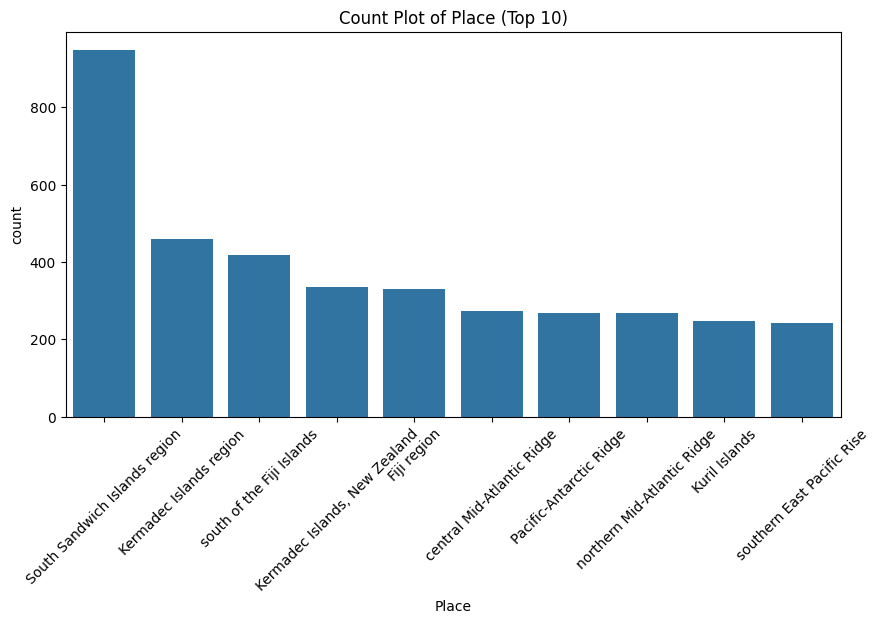

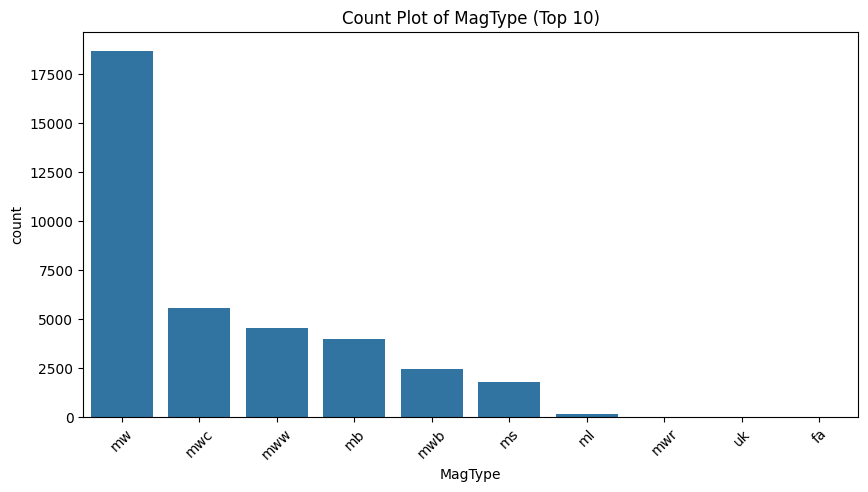

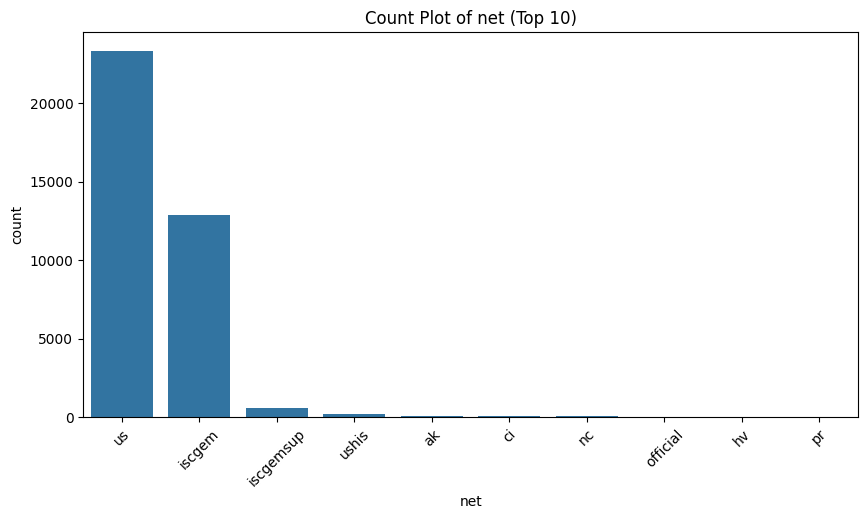

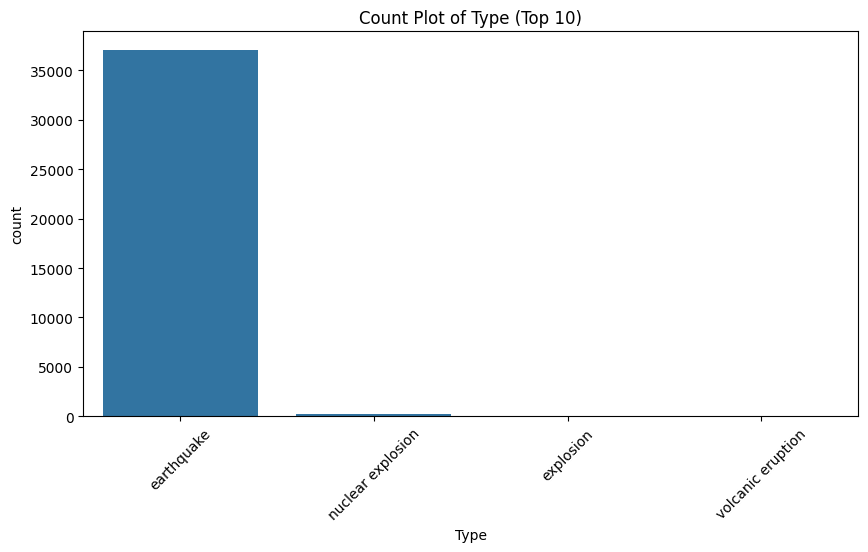

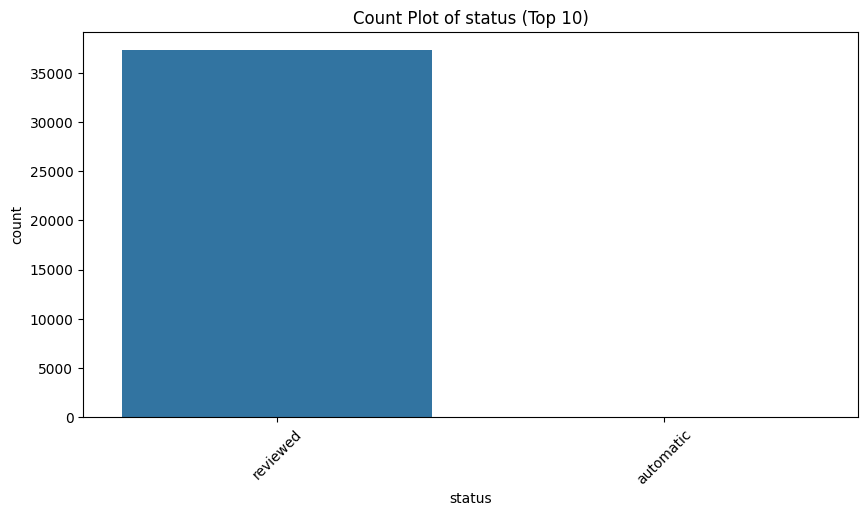

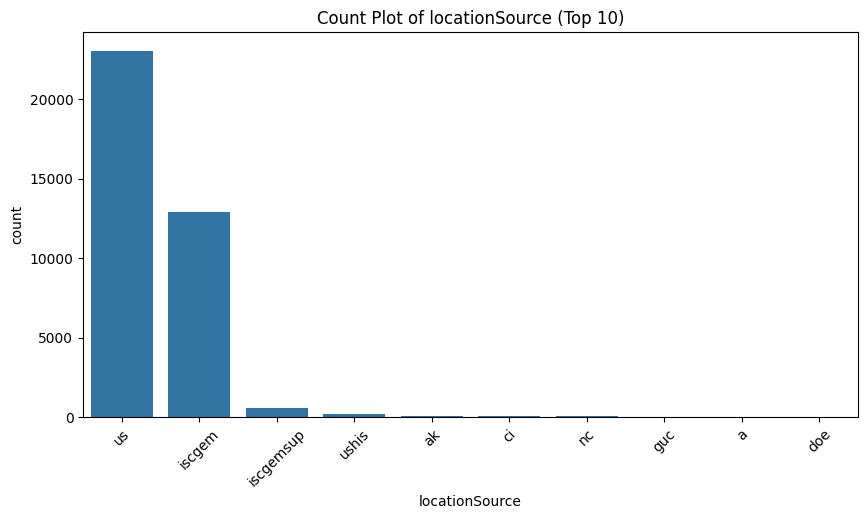

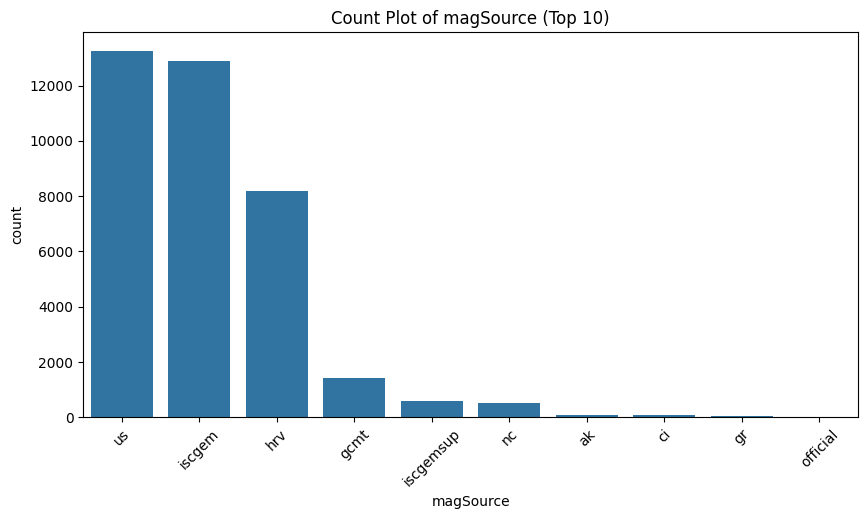

In [650]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = [
    'Place', 'MagType', 'net', 'Type',
    'status', 'locationSource', 'magSource'
]

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index[:10])
    plt.title(f'Count Plot of {col} (Top 10)')
    plt.xticks(rotation=45)
    plt.show()




* Rare magnitude types occur very infrequently.
* Majority of records belong to earthquake events.
* Most events are marked as reviewed.
* Data is largely contributed by a limited number of sources.
* Few sources contribute minimal records.
* Several networks appear infrequently.
* Earthquake occurrences are concentrated in specific regions.
* Most categorical features show imbalanced distributions.

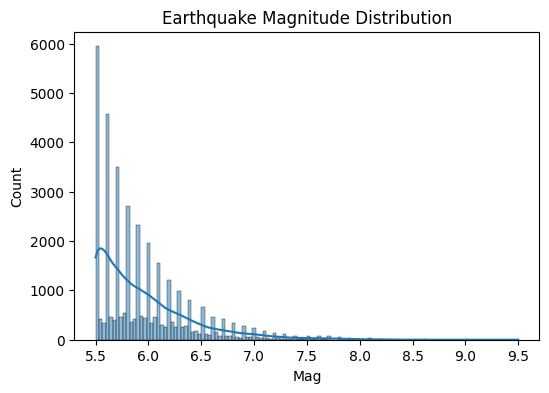

In [651]:

# Target distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Mag"], kde=True)
plt.title("Earthquake Magnitude Distribution")
plt.show()

## Encoding

In [652]:
from sklearn.preprocessing import LabelEncoder

object_cols = ['Place', 'MagType', 'net', 'Type', 'status', 'locationSource', 'magSource']

encoders = {}

for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [653]:
df['Time'] = pd.to_datetime(df['Time'])

df['year'] = df['Time'].dt.year
df['month'] = df['Time'].dt.month
df['day'] = df['Time'].dt.day
df['hour'] = df['Time'].dt.hour

# Drop original Time
df.drop(columns=['Time'], inplace=True)

In [654]:
df.isnull().sum()

Place             0
Latitude          0
Longitude         0
Depth             0
Mag               0
MagType           0
net               0
Type              0
status            0
locationSource    0
magSource         0
year              0
month             0
day               0
hour              0
dtype: int64

## Data Transformation

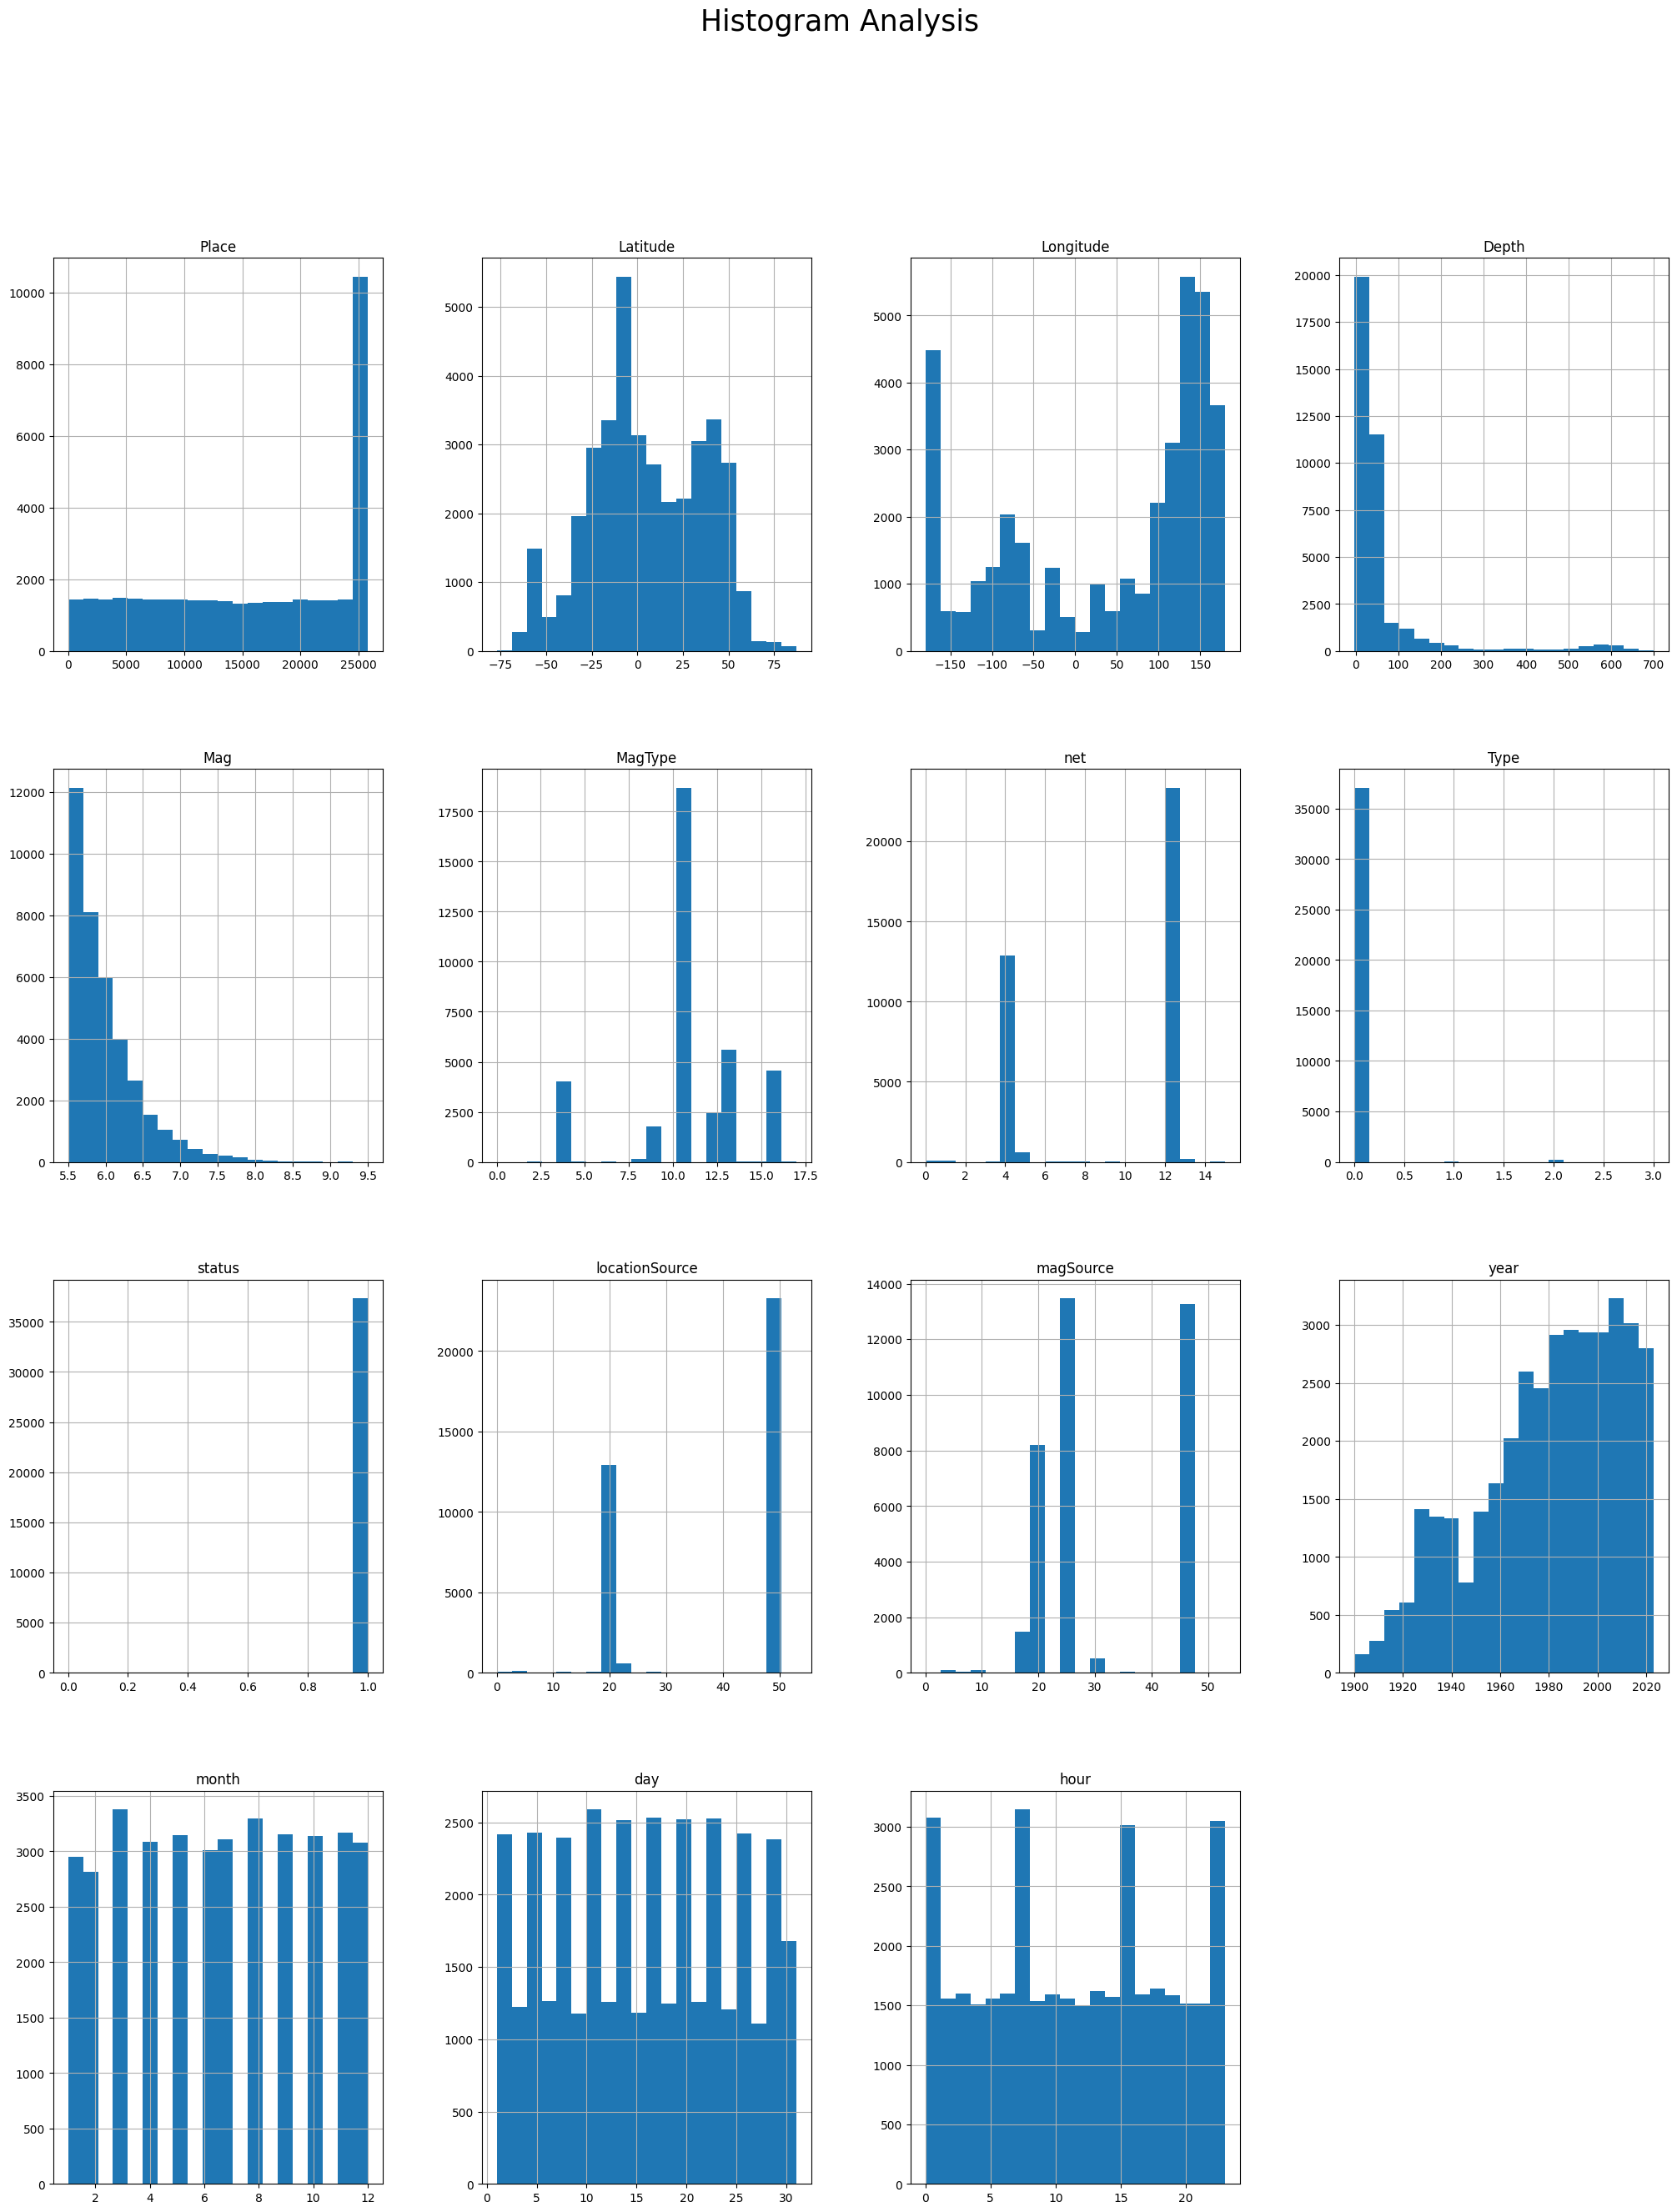

In [655]:
df.hist(bins=20, figsize=(25,30))
plt.suptitle(" Histogram Analysis", fontsize=25)
plt.show()

## Skewned Data

In [656]:
# calculate skewness for each column

skewness = df.skew()

# sort the skewness values in ascending order

sorted_skewness = skewness.sort_values(ascending=True)

# Display the sorted skewness values

print(sorted_skewness)

status           -51.611185
MagType           -0.861048
Longitude         -0.591205
net               -0.566010
locationSource    -0.565982
year              -0.563972
Place             -0.305180
Latitude          -0.054264
month             -0.014532
hour               0.002635
day                0.007677
magSource          0.435634
Mag                1.646315
Depth              3.853526
Type              12.184515
dtype: float64


In [657]:
# import numpy as np

# df['Depth'] = np.log1p(df['Depth'])
# df['Mag'] = np.log1p(df['Mag'])
# df['Type'] = np.log1p(df['Type'])


In [658]:
# # calculate skewness for each column

# skewness = df.skew()

# # sort the skewness values in ascending order

# sorted_skewness = skewness.sort_values(ascending=True)

# # Display the sorted skewness values

# print(sorted_skewness)

## Heat Map

<Axes: >

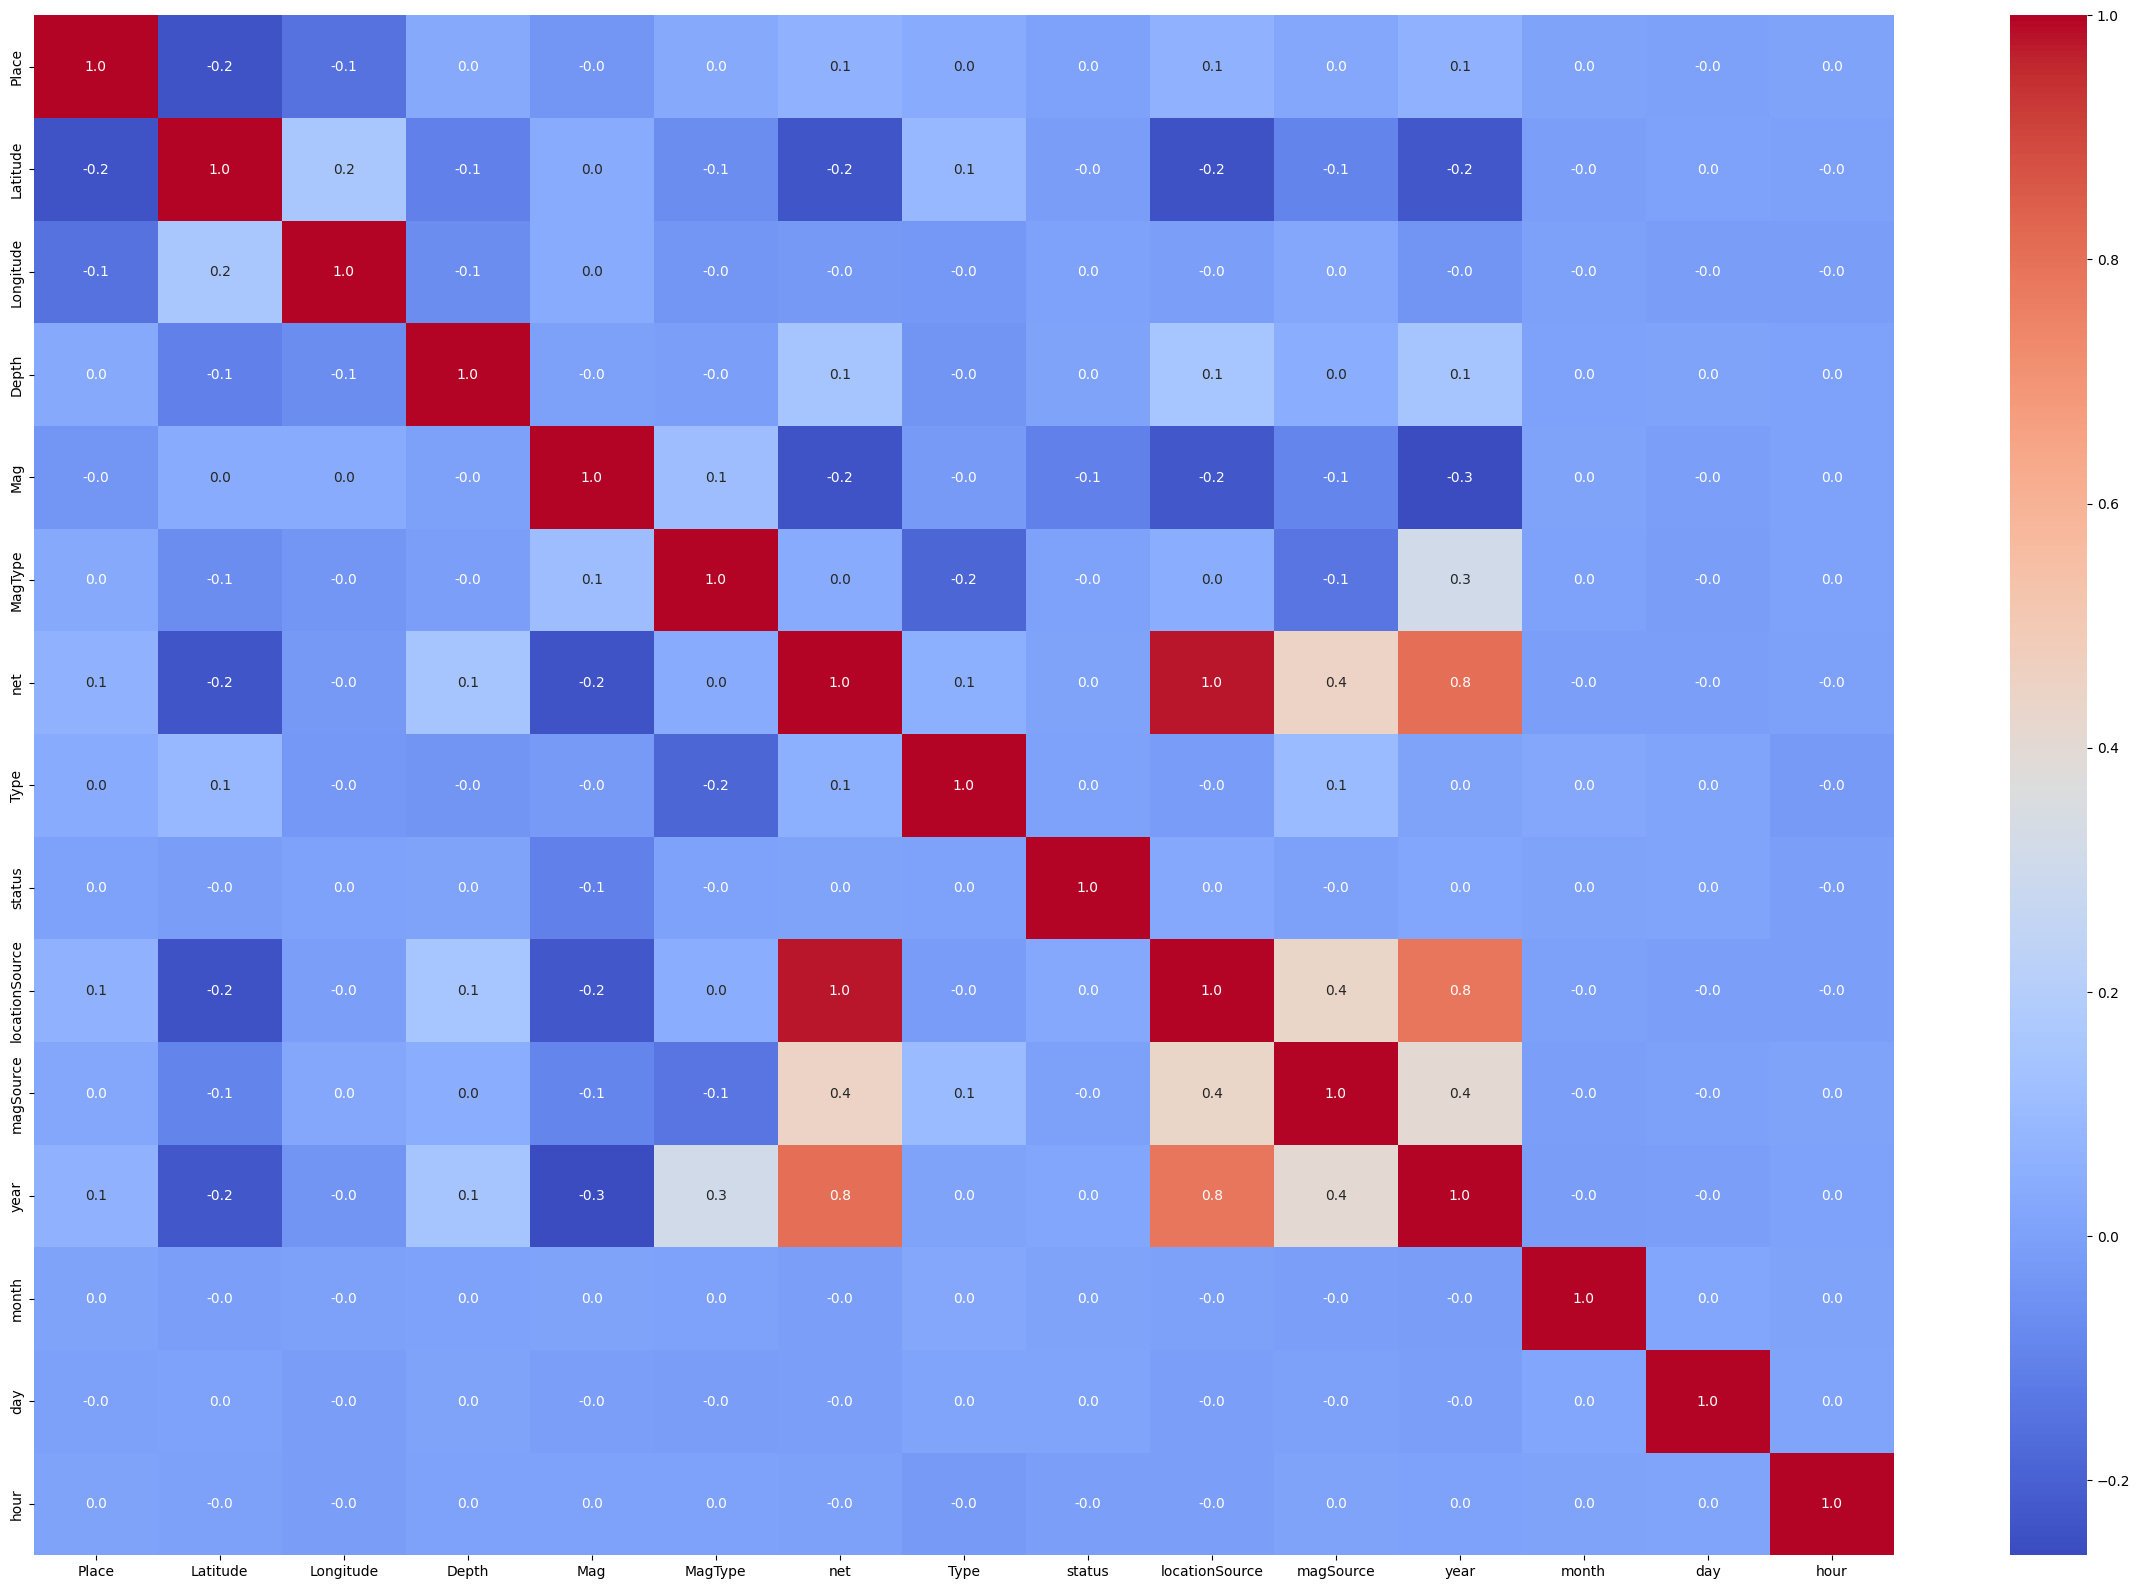

In [659]:
plt.figure(figsize=(30,20))
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt="0.01f")

In [660]:
correlation_matrix = df.corr()

threshold =0.5 # set the correlation threshold

# Find pairs of features with high correlation

highly_correlation_pairs =[]
for i in range (len(correlation_matrix.columns)):
    for j in range(i):
        # check if the absolute correlation exceeds the threshold
        if abs(correlation_matrix.iloc[i,j])> threshold:
            highly_correlation_pairs.append((correlation_matrix.columns[i],correlation_matrix.columns[j]))
            
# print all pairs of highly correlation features

print(highly_correlation_pairs) 
            

[('locationSource', 'net'), ('year', 'net'), ('year', 'locationSource')]


In [661]:
df["Place"].unique()

array([ 4098, 21004, 25522, ..., 11022,  2798,  6899])

## Box plot Visualization

In [662]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37331 entries, 0 to 37330
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Place           37331 non-null  int32  
 1   Latitude        37331 non-null  float64
 2   Longitude       37331 non-null  float64
 3   Depth           37331 non-null  float64
 4   Mag             37331 non-null  float64
 5   MagType         37331 non-null  int32  
 6   net             37331 non-null  int32  
 7   Type            37331 non-null  int32  
 8   status          37331 non-null  int32  
 9   locationSource  37331 non-null  int32  
 10  magSource       37331 non-null  int32  
 11  year            37331 non-null  int32  
 12  month           37331 non-null  int32  
 13  day             37331 non-null  int32  
 14  hour            37331 non-null  int32  
dtypes: float64(4), int32(11)
memory usage: 2.7 MB


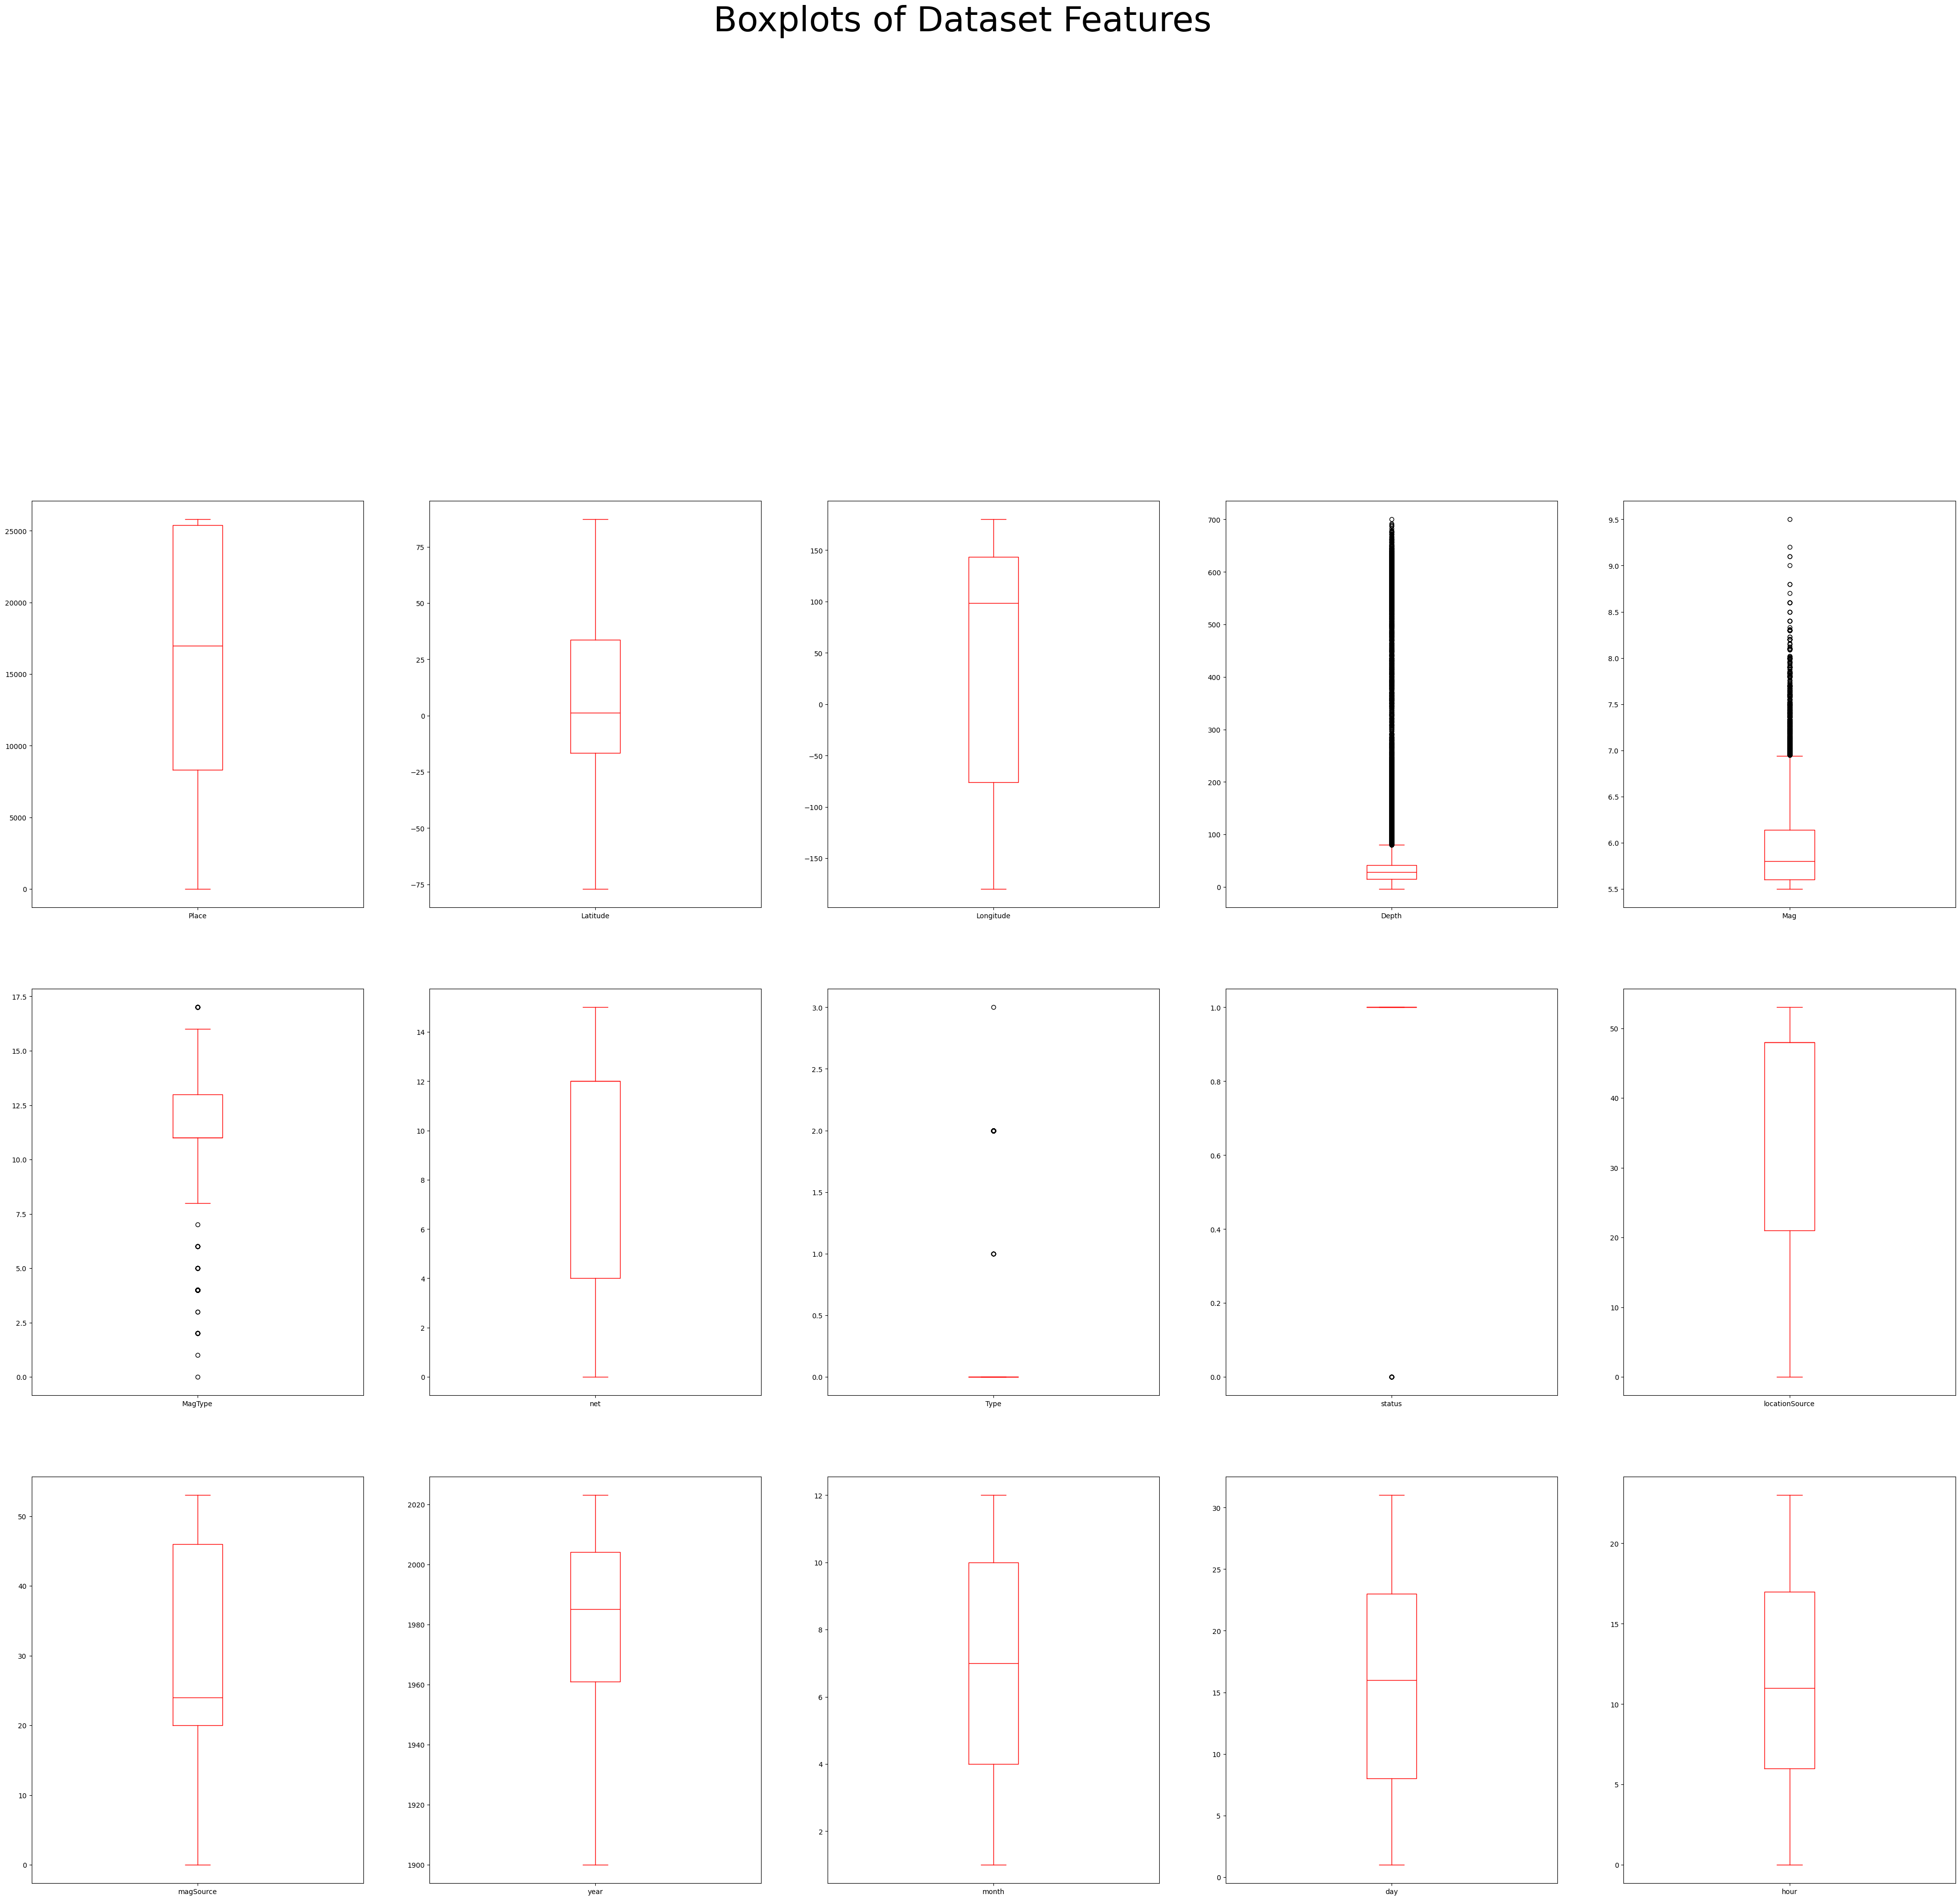

In [663]:
df.plot(kind="box",subplots=True,layout=(8,5),figsize=(50,100),color="red")
plt.suptitle("Boxplots of Dataset Features",fontsize=50)
plt.show()

## Handle Outliears

In [664]:
# create a copy of the original data for comparison


def remove_outliers_iqr(df,exclude_columns):
    # Loop through numeric columns
    for column in df.select_dtypes(include=["number"]):
        if column in exclude_columns:
            continue # skip excluded columns
        
        Q1=df[column].quantile(0.25)
        Q3=df[column].quantile(0.75)
        IQR=Q3-Q1
        
        # Define outlier bounds
        lower_bound = Q1-1.5*IQR
        upper_bound = Q3+1.5*IQR
        
        
        # Filter out the outliers
        
        df=df[(df[column] >=lower_bound) & (df[column] <= upper_bound)]
        
    return df 

# Define the columns to exclude (target and descrete columns)

exclude_columns =["Depth","Type"]

# Remove outliers
df=remove_outliers_iqr(df,exclude_columns)

In [665]:
X = df.drop(columns=["Mag"])
y = df["Mag"]


In [666]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [667]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_features = X_train.select_dtypes(include="number").columns

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])


## Model Building

In [668]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Model Evaluation

In [669]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 0.2696124684206739
RMSE: 0.3362590824543295
R2  : 0.09982656234466414


## Save Model (Pickle File)

In [670]:
import pickle

with open("earthquake_magnitude_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("✅ Model saved as earthquake_magnitude_model.pkl")



✅ Model saved as earthquake_magnitude_model.pkl


In [671]:
df.columns

Index(['Place', 'Latitude', 'Longitude', 'Depth', 'Mag', 'MagType', 'net',
       'Type', 'status', 'locationSource', 'magSource', 'year', 'month', 'day',
       'hour'],
      dtype='object')

In [672]:
import gradio as gr

from datetime import datetime

# Load model
with open("earthquake_magnitude_model.pkl", "rb") as f:
    model = pickle.load(f)

# Prediction function
def predict_mag(Time, Place, Latitude, Longitude, Depth,
                MagType, net, Type, status, locationSource, magSource):

    # Convert time to timestamp
    time_val = pd.to_datetime(Time).timestamp()

    # Encode categorical values
    Place = encoders['Place'].transform([Place])[0]
    MagType = encoders['MagType'].transform([MagType])[0]
    net = encoders['net'].transform([net])[0]
    Type = encoders['Type'].transform([Type])[0]
    status = encoders['status'].transform([status])[0]
    locationSource = encoders['locationSource'].transform([locationSource])[0]
    magSource = encoders['magSource'].transform([magSource])[0]

    # Create input array
    input_data = np.array([[time_val, Place, Latitude, Longitude, Depth,
                             MagType, net, Type, status, locationSource, magSource]])

    prediction = model.predict(input_data)[0]

    return f"Predicted Earthquake Magnitude: {prediction:.2f}"

# Gradio UI
interface = gr.Interface(
    fn=predict_mag,
    inputs=[
        gr.Textbox(label="Time (YYYY-MM-DD HH:MM:SS)"),
        gr.Textbox(label="Place"),
        gr.Number(label="Latitude"),
        gr.Number(label="Longitude"),
        gr.Number(label="Depth (km)"),
        gr.Textbox(label="MagType"),
        gr.Textbox(label="Net"),
        gr.Textbox(label="Type"),
        gr.Textbox(label="Status"),
        gr.Textbox(label="Location Source"),
        gr.Textbox(label="Mag Source")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🌍 Earthquake Magnitude Prediction System",
    description="Predict earthquake magnitude using seismic parameters"
)

interface.launch()


* Running on local URL:  http://127.0.0.1:7875

To create a public link, set `share=True` in `launch()`.
